In [24]:
# QUESTION 1
# Social Capital


# 1. Import packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set(style="whitegrid")

In [3]:
# 2. Load the datasets
atlas = pd.read_csv("../data/q1_atlas_outcomes.csv")
social = pd.read_csv("../data/q1_social_capital_county.csv")

atlas.head(), social.head()

(   state  county  kfr_pooled_pooled_p25  kfr_pooled_pooled_p75
 0      0       0               0.427177               0.590823
 1      1       0               0.372331               0.566848
 2      1       1               0.361666               0.574681
 3      1       3               0.388847               0.565526
 4      1       5               0.349386               0.560583,
    county             county_name  ec_county  ec_high_county
 0       0        National average   0.814464        1.252636
 1    1000  State average, Alabama   0.595470        1.066775
 2    1001        Autauga, Alabama   0.720770        1.213720
 3    1003        Baldwin, Alabama   0.743130        1.283020
 4    1005        Barbour, Alabama   0.413660        0.918970)

In [4]:
# Inspect the first few rows
atlas.columns, social.columns

(Index(['state', 'county', 'kfr_pooled_pooled_p25', 'kfr_pooled_pooled_p75'], dtype='object'),
 Index(['county', 'county_name', 'ec_county', 'ec_high_county'], dtype='object'))

In [5]:
# Attempt merge based on county
merged = atlas.merge(social, on="county", how="inner") 
merged.head()

,state,county,kfr_pooled_pooled_p25,kfr_pooled_pooled_p75,county_name,ec_county,ec_high_county
0,0,0,0.427177,0.590823,National average,0.814464,1.252636
1,1,0,0.372331,0.566848,National average,0.814464,1.252636
2,2,0,0.343465,0.464647,National average,0.814464,1.252636
3,4,0,0.394139,0.546727,National average,0.814464,1.252636
4,5,0,0.391261,0.574292,National average,0.814464,1.252636


In [6]:
# 3. Inspect county identifiers
atlas['county'].head(10), social['county'].head(10)

(0     0
 1     0
 2     1
 3     3
 4     5
 5     7
 6     9
 7    11
 8    13
 9    15
 Name: county, dtype: int64,
 0       0
 1    1000
 2    1001
 3    1003
 4    1005
 5    1007
 6    1009
 7    1011
 8    1013
 9    1015
 Name: county, dtype: int64)

In [7]:
# 4. Create FIPS county identifier
# Atlas: FIPS = state * 1000 + county
atlas['fips'] = atlas['state']*1000+atlas['county']

In [8]:
# Social Capital:
# The county variable already corresponds to the FIPS code
social['fips'] = social['county']

In [9]:
# 5. Merge datasets
# Use an inner join so that only counties present in both
# datasets are included in the analysis.
merged = atlas.merge(social, on='fips', how='inner')
merged.head()

,state,county_x,kfr_pooled_pooled_p25,kfr_pooled_pooled_p75,fips,county_y,county_name,ec_county,ec_high_county
0,0,0,0.427177,0.590823,0,0,National average,0.814464,1.252636
1,1,0,0.372331,0.566848,1000,1000,"State average, Alabama",0.595470,1.066775
2,1,1,0.361666,0.574681,1001,1001,"Autauga, Alabama",0.720770,1.213720
3,1,3,0.388847,0.565526,1003,1003,"Baldwin, Alabama",0.743130,1.283020
4,1,5,0.349386,0.560583,1005,1005,"Barbour, Alabama",0.413660,0.918970


In [10]:
merged.shape

(3141, 9)

In [25]:
summary = merged.describe(percentiles=[0.25, 0.5, 0.75]).T
summary['n'] = merged.count()
summary = summary[['mean', 'min', '25%', '50%', '75%', 'max', 'n']]
summary

,mean,min,25%,50%,75%,max,n
state,30.090735,0.000000,18.000000,29.000000,45.000000,56.000000,3141
kfr_pooled_pooled_p25,0.433798,-0.144350,0.386554,0.421304,0.461266,4.959184,3141
kfr_pooled_pooled_p75,0.599083,-0.156952,0.563935,0.590666,0.622236,4.791885,3141
fips,30188.736390,0.000000,18155.000000,29133.000000,45043.000000,56045.000000,3141
ec_county,0.815030,0.294690,0.696742,0.807775,0.938373,1.359700,3070
ec_high_county,1.253287,0.700620,1.135420,1.258635,1.384657,1.715070,3070


In [12]:
# Drop county_x and county_y
merged = merged.drop(columns=["county_x", "county_y"])

In [13]:
# 6. Summary statistics
summary = merged.describe(percentiles=[0.25, 0.5, 0.75]).T
summary['n'] = merged.count()
summary = summary[['mean', 'min', '25%', '50%', '75%', 'max', 'n']]
summary

,mean,min,25%,50%,75%,max,n
state,30.090735,0.000000,18.000000,29.000000,45.000000,56.000000,3141
kfr_pooled_pooled_p25,0.433798,-0.144350,0.386554,0.421304,0.461266,4.959184,3141
kfr_pooled_pooled_p75,0.599083,-0.156952,0.563935,0.590666,0.622236,4.791885,3141
fips,30188.736390,0.000000,18155.000000,29133.000000,45043.000000,56045.000000,3141
ec_county,0.815030,0.294690,0.696742,0.807775,0.938373,1.359700,3070
ec_high_county,1.253287,0.700620,1.135420,1.258635,1.384657,1.715070,3070


In [14]:
# Merge state and fips
merged_clean = merged.drop(columns=["state", "fips"])

In [15]:
# Clean Summary statistics
summary = merged_clean.describe(percentiles=[0.25, 0.5, 0.75]).T
summary["n"] = merged_clean.count()
summary = summary[["mean", "min", "25%", "50%", "75%", "max", "n"]]
summary

,mean,min,25%,50%,75%,max,n
kfr_pooled_pooled_p25,0.433798,-0.144350,0.386554,0.421304,0.461266,4.959184,3141
kfr_pooled_pooled_p75,0.599083,-0.156952,0.563935,0.590666,0.622236,4.791885,3141
ec_county,0.815030,0.294690,0.696742,0.807775,0.938373,1.359700,3070
ec_high_county,1.253287,0.700620,1.135420,1.258635,1.384657,1.715070,3070


In [16]:
#7. Save merged dataset and summary statistics
merged.to_csv("../output/q1_merged_dataset.csv", index=False)

In [17]:
summary.to_csv("../output/q1_summary_statistics.csv")

In [19]:
import numpy as np
import pandas as pd

# 8. Create low-SES bins
# Economic connectedness is divided into 20 quantile bins.
# For each bin, calculate:
#   x = mean economic connectedness
#   y = mean intergenerational mobility
merged['ec_low_bin'] = pd.qcut(merged['ec_county'], q=20, duplicates='drop')
low_binned = merged.groupby('ec_low_bin', observed=True).agg(
    x=('ec_county', 'mean'),
    y=('kfr_pooled_pooled_p25', 'mean')
).reset_index()

# 9. Create high-SES bins
# Economic connectedness is divided into 20 quantile bins.
# For each bin, calculate:
#   x = mean economic connectedness
#   y = mean intergenerational mobility
merged['ec_high_bin'] = pd.qcut(merged['ec_high_county'], q=20, duplicates='drop')
high_binned = merged.groupby('ec_high_bin', observed=True).agg(
    x=('ec_high_county', 'mean'),
    y=('kfr_pooled_pooled_p75', 'mean')
).reset_index()

In [21]:
import statsmodels.api as sm

# 10. Run regression for low SES
# Regress binned intergenerational mobility on binned
# economic connectedness.
X_low = sm.add_constant(low_binned['x'])
model_low = sm.OLS(low_binned['y'], X_low).fit()

# 11. Run regression for high SES
X_high = sm.add_constant(high_binned['x'])
model_high = sm.OLS(high_binned['y'], X_high).fit()

# 12. Display regression results
print("Low SES slope:", model_low.params[1])
print("Low SES SE:", model_low.bse[1])

print("High SES slope:", model_high.params[1])
print("High SES SE:", model_high.bse[1])

Low SES slope: 0.23501271617821537
Low SES SE: 0.01271958234065491
High SES slope: 0.11207838863486977
High SES SE: 0.012420086975764936


/var/folders/kj/dc3wg8m1665f7k89vc_95bz80000gn/T/ipykernel_71403/2961455586.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Low SES slope:", model_low.params[1])
/var/folders/kj/dc3wg8m1665f7k89vc_95bz80000gn/T/ipykernel_71403/2961455586.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Low SES SE:", model_low.bse[1])
/var/folders/kj/dc3wg8m1665f7k89vc_95bz80000gn/T/ipykernel_71403/2961455586.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value 

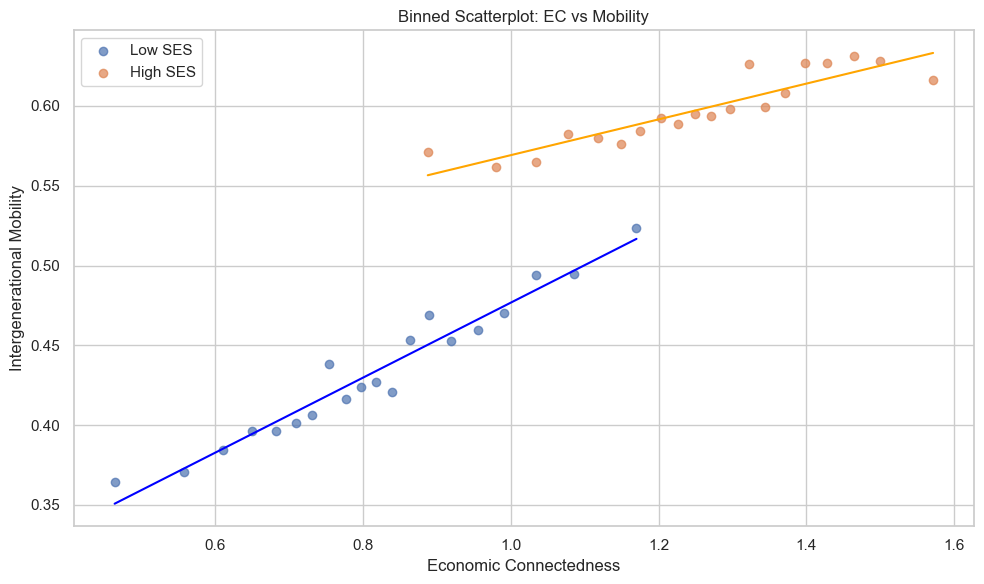

In [22]:
# 13. Create binned scatterplot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Low SES
plt.scatter(low_binned['x'], low_binned['y'], label='Low SES', alpha=0.7)
plt.plot(low_binned['x'], model_low.predict(X_low), color='blue')

# High SES
plt.scatter(high_binned['x'], high_binned['y'], label='High SES', alpha=0.7)
plt.plot(high_binned['x'], model_high.predict(X_high), color='orange')

plt.xlabel("Economic Connectedness")
plt.ylabel("Intergenerational Mobility")
plt.title("Binned Scatterplot: EC vs Mobility")
plt.legend()
plt.tight_layout()
plt.show()